In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
data = pd.read_csv("12-house_energy_regression.csv")

In [6]:
# avg_indoor_temp_change -> Change in indoor temperature over the past 24h (°C)
# outdoor_humidity_level -> Relative outdoor humidity (%)
# daily_energy_consumption_kwh -> Energy usage (in kWh) for the household over one day

In [3]:
data

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530
...,...,...,...
995,-0.753965,-0.280675,-33.182365
996,-2.172670,0.847422,-71.059718
997,0.302635,-0.754276,3.260515
998,0.381935,0.430042,42.654703


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [5]:
data.isnull().sum()

avg_indoor_temp_change          0
outdoor_humidity_level          0
daily_energy_consumption_kwh    0
dtype: int64

In [7]:
data.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


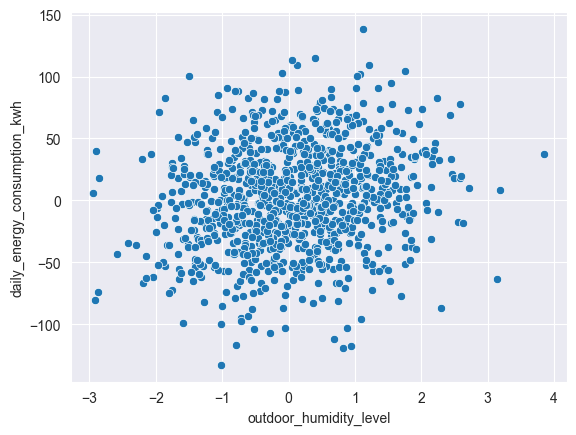

In [8]:
sns.scatterplot(x = data["outdoor_humidity_level"], y = data["daily_energy_consumption_kwh"])
plt.show()

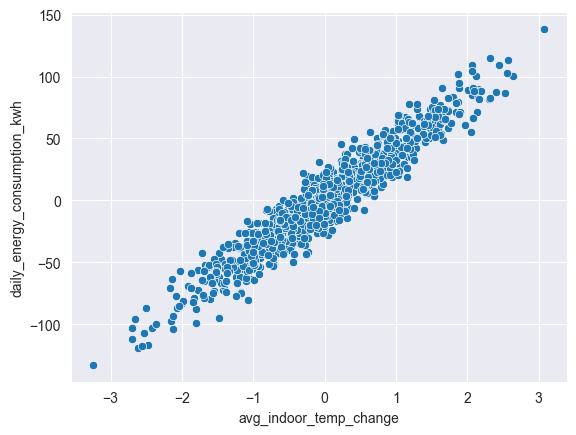

In [9]:
sns.scatterplot(x = data["avg_indoor_temp_change"], y = data["daily_energy_consumption_kwh"])
plt.show()

In [10]:
data.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


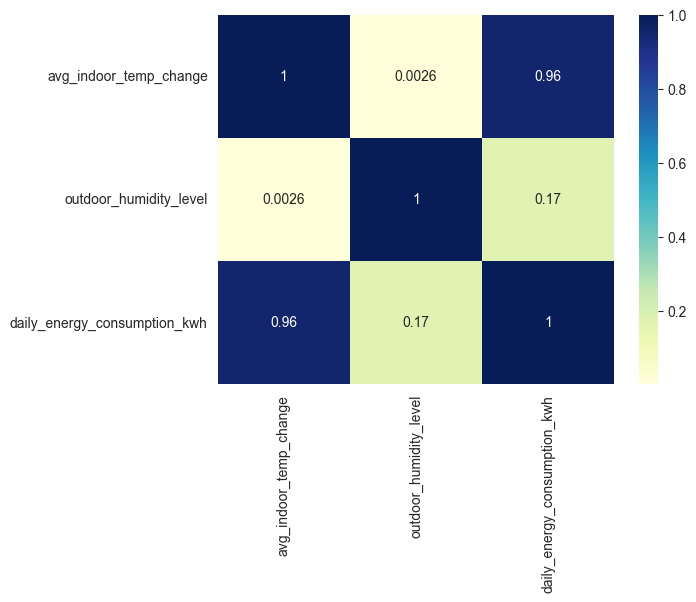

In [13]:
sns.heatmap(data.corr(), annot=True, cmap="YlGnBu")
plt.show()

In [14]:
X = data.drop("daily_energy_consumption_kwh", axis = 1)
y = data["daily_energy_consumption_kwh"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.neighbors import KNeighborsRegressor

In [21]:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
regressor = KNeighborsRegressor(n_neighbors=5, algorithm='auto')

In [22]:
regressor.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
y_pred = regressor.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

R2 Score:  0.9152685146562609
Mean Absolute Error:  9.42143518926242
Mean Squared Error:  140.40201685069158


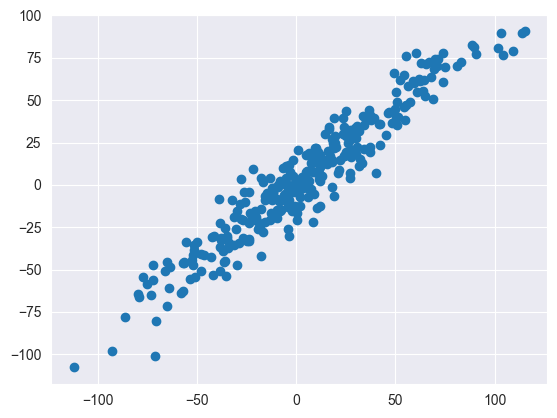

In [27]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.show()

R2 Score:  0.9164863388635838
Mean Absolute Error:  9.331428506491209
Mean Squared Error:  138.3840541750219


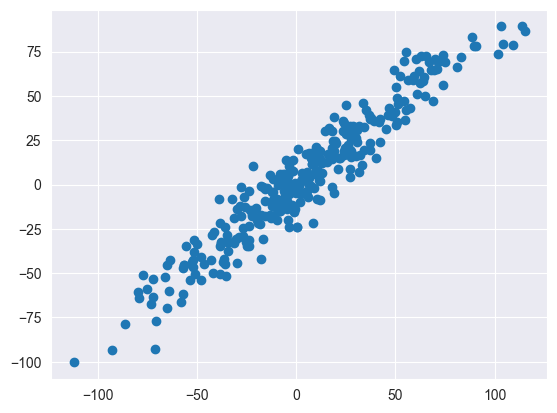

In [33]:
regressor = KNeighborsRegressor(n_neighbors=7, algorithm='auto')
regressor.fit(X_train_scaled, y_train)
y_pred = regressor.predict(X_test_scaled)

print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.show()